In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = "Proyecto Inicial"

## Classic Chat Agent Executor

#### It's a basic flow where the user makes a question and the LLM determines if needs to use a tool and answer

In [2]:
import operator
from typing import Annotated, TypedDict, Literal

from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

/home/santi/Documentos/LangGraph/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
@tool
def get_crypto_price(ticker: str):
    """Returns the current price of a cryptocurrency. ticker should be something like 'BTC' or 'ETH'."""
    # We simulate an API call
    prices = {"BTC": "65,000 USD", "ETH": "3,500 USD", "SOL": "140 USD"}
    return f"The price of {ticker} is {prices.get(ticker.upper(), 'unknown')}."

@tool
def get_dia():
    """Returns the current day."""
    import datetime
    return f"{datetime.datetime.now().strftime('%Y-%m-%d')}."

tools = [get_crypto_price, get_dia]

In [4]:
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0).bind_tools(tools)

In [5]:

# State
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# Model function call
def call_model(state: AgentState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

# Tool Node
tool_node = ToolNode(tools)

In [6]:
# Flow Control
def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    # If the model called a tool, we need to execute it
    if last_message.tool_calls:
        return "tools"
    # If not, we end the execution
    return END

In [7]:
# Graph Construction
workflow = StateGraph(AgentState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.set_entry_point("agent")

workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tools", "agent")

app = workflow.compile()

In [8]:
from langchain_core.tracers.context import tracing_v2_enabled
from langchain_core.messages import SystemMessage, HumanMessage

inputs = {
    "messages": [
        SystemMessage(content="You are a technical assistant. Use tools only if necessary. If a tool has already given you the answer, use it to respond to the user immediately and end."),
        HumanMessage(content="What day is it today?")
    ]
}

with tracing_v2_enabled(project_name="Proyecto Inicial"):
    for output in app.stream(inputs):
        print(output)

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'w0xfn8x9v', 'function': {'arguments': '{}', 'name': 'get_dia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 321, 'total_tokens': 330, 'completion_time': 0.030325605, 'completion_tokens_details': None, 'prompt_time': 0.037962092, 'prompt_tokens_details': None, 'queue_time': 0.193334221, 'total_time': 0.068287697}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dd516-0269-7673-9340-507e3e1718e1-0', tool_calls=[{'name': 'get_dia', 'args': {}, 'id': 'w0xfn8x9v', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 321, 'output_tokens': 9, 'total_tokens': 330})]}}
{'tools': {'messages': [ToolMessage(content='2026-04-28.', name='get_dia', id='7db9c1b0-fca4-473c-a7dd-26ba6fff70

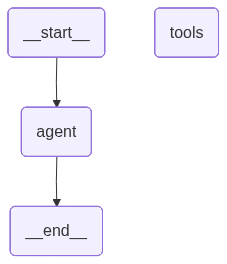

In [9]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

## Dynamically decides whether to send the tool's answer directly to the user or to preprocess it first

#### In some cases it is convenient to send the answer directly to the user in an established format for the tool

In [10]:
from pydantic import BaseModel, Field

class GetDiaSchema(BaseModel):
    return_directly: bool = Field(
        default=False,
        description="""Set this to True ONLY if the user asks for the date in a simple way
        (e.g., 'what day is it today?'). Set this to False if the date is part of a more complex question that requires your further analysis."""
    )

@tool(args_schema=GetDiaSchema)
def get_dia(return_directly: bool = False):
    """Returns the current day."""
    import datetime
    return "Today is Thursday, April 16, 2026."

In [11]:
import json

def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]

    # 1. If there are NO tool calls, the flow ends normally 
    if not last_message.tool_calls:
        return END

    # 2. If there ARE tool calls, we check if the model requested "return_directly"
    # Get the arguments of the first call to the tool (assuming only one call for simplicity)
    tool_call = last_message.tool_calls[0]
    tool_args = tool_call.get("args", {})

    # Handling safety in case Groq returns a JSON string
    if isinstance(tool_args, str):
        try:
            tool_args = json.loads(tool_args)
            print(f"Tool's arguments: {tool_args}")
        except:
            tool_args = {}
            print("Error loading tool's arguments.")

    # 3. THE DYNAMIC DECISION:
    # If the model set True in 'return_directly', we send it to a node 
    # that ends the flow (final_response -> END)
    if tool_args.get("return_directly") is True:
        print("The model requested a direct response. Ending flow.")
        return "final_response"
    
    # If not, we continue the normal path for the agent to process the result
    return "tools"

In [12]:
tools = [get_crypto_price, get_dia]
tool_executor = {tool.name: tool for tool in tools} # {"get_dia": get_dia, "get_crypto_price": get_crypto_price}
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0).bind_tools(tools)

def call_model(state: AgentState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [13]:
import json
from langchain_core.messages import ToolMessage

def custom_tool_node(state : AgentState):
    messages = state["messages"]
    last_message = messages[-1]

    if not hasattr(last_message, "tool_calls") or not last_message.tool_calls:
        return {"messages": []}

    # 1. Acceso seguro al primer tool_call
    # Usamos .tool_calls[0] que es el estándar moderno, 
    # pero mantenemos la extracción de argumentos compatible con el formato JSON
    tool_call = last_message.tool_calls[0]
    tool_name = tool_call["name"]
    tool_id = tool_call["id"]
    
    # 2. EL ARREGLO CRÍTICO: 
    # Si 'args' es un string, lo convertimos a dict. Si ya es dict, lo usamos.
    tool_args = tool_call["args"]
    if isinstance(tool_args, str):
        tool_args = json.loads(tool_args)

    # 3. Lógica dinámica de return_directly
    # Usamos .get() para evitar KeyErrors si el parámetro no existe
    if tool_args.get("return_directly") is True:
        # Guardamos el flag si lo necesitamos, o simplemente limpiamos
        del tool_args["return_directly"]

    # 4. Ejecución
    # Importante: Usamos **tool_args para desempaquetar el diccionario
    tool_response = tool_executor[tool_name].invoke(tool_args)
    
    tool_message = ToolMessage(
        content=str(tool_response),
        tool_call_id=tool_id,
        name=tool_name
    )

    return {"messages": [tool_message]}

In [14]:
workflow = StateGraph(AgentState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", custom_tool_node) # <-- We use our custom function
workflow.add_node("final_response", custom_tool_node)

workflow.set_entry_point("agent")
workflow.add_conditional_edges("agent", should_continue)

workflow.add_edge("tools", "agent")
workflow.add_edge("final_response", END)

app = workflow.compile()

In [15]:
from langchain_core.tracers.context import tracing_v2_enabled
from langchain_core.messages import SystemMessage, HumanMessage

inputs = {
    "messages": [
        SystemMessage(content="""You are an assistant that ONLY responds using tools. 
        If the user asks for the date, you MUST call 'get_dia'. 
        Do not respond with plain text or JSON code blocks, use the function directly.
        If the question is simple and direct about the date, use 'return_directly=True' so that the agent responds immediately with the tool result.
        If you already got the response from the tool, use it to respond to the user and finish.              
        """),
        HumanMessage(content="Tell me a phrase that includes today's date.") 
    ]
}

# This forces everything that happens inside to be sent to LangSmith
with tracing_v2_enabled(project_name="Proyecto Inicial"):
    for output in app.stream(inputs):
        print(output)

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'y9v0mqh37', 'function': {'arguments': '{"return_directly":false}', 'name': 'get_dia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 452, 'total_tokens': 467, 'completion_time': 0.042289415, 'completion_tokens_details': None, 'prompt_time': 0.091134312, 'prompt_tokens_details': None, 'queue_time': 0.153075373, 'total_time': 0.133423727}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dd516-0950-76d0-8330-8812e7cc0a58-0', tool_calls=[{'name': 'get_dia', 'args': {'return_directly': False}, 'id': 'y9v0mqh37', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 452, 'output_tokens': 15, 'total_tokens': 467})]}}
{'tools': {'messages': [ToolMessage(content='Today is Thursday, 

## Defined format for Responses

In [16]:
import json

def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]

    # 1. If there are NO tool calls, the flow ends normally
    if not last_message.tool_calls:
        return END

    if last_message.tool_calls[0]["name"] == "Response":
        return END
    
    return "tools"

In [17]:
@tool()
def get_dia():
    """Returns the current day."""
    import datetime
    return datetime.datetime.now().strftime('%Y-%m-%d')

In [18]:
import datetime
from langchain_core.utils.function_calling import convert_to_openai_function

class Response(BaseModel):
    """Final response schema for the user."""
    date: datetime.date
    complete_response: str = "Complete response for the user, including the date and any other relevant details."

tools = [get_dia, Response]
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0).bind_tools(tools)

def call_model(state: AgentState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [19]:
workflow = StateGraph(AgentState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.set_entry_point("agent")

workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tools", "agent")

app = workflow.compile()

In [20]:
from langchain_core.tracers.context import tracing_v2_enabled
from langchain_core.messages import SystemMessage, HumanMessage

inputs = {
    "messages": [
        SystemMessage(content="You are a technical assistant. Use tools only if necessary. If a tool has already given you the answer, use it to respond to the user immediately and end."),
        HumanMessage(content="What day is it today?")
    ]
}

# This forces everything that happens inside to be sent to LangSmith
with tracing_v2_enabled(project_name="Proyecto Inicial"):
    for output in app.stream(inputs):
        print(output)

# At the end, you can access the data like this:
final_message = output['agent']['messages'][-1]
if final_message.tool_calls:
    res = final_message.tool_calls[0]['args']
    print(f"Date: {res['date']}")
    print(f"Response: {res['complete_response']}")

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'dxsqves2d', 'function': {'arguments': '{}', 'name': 'get_dia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 317, 'total_tokens': 326, 'completion_time': 0.016015073, 'completion_tokens_details': None, 'prompt_time': 0.033506706, 'prompt_tokens_details': None, 'queue_time': 0.243353859, 'total_time': 0.049521779}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dd516-0dff-7431-a59c-c018e99fe11a-0', tool_calls=[{'name': 'get_dia', 'args': {}, 'id': 'dxsqves2d', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 317, 'output_tokens': 9, 'total_tokens': 326})]}}
{'tools': {'messages': [ToolMessage(content='2026-04-28.', name='get_dia', id='287bd7a6-81d1-4212-9e59-7dbce4479d